In [ ]:
# https://www.kaggle.com/datasets/shashwatwork/eeg-psychiatric-disorders-dataset

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk import ConfusionMatrix
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import time
import seaborn as sns

In [4]:
# This data contains brain activity recorded from 1,142 different individuals.
# Wave activity was recorded by each patient while resting with eyes closed for several minutes.

MLF = pd.read_csv('EEG.machinelearing_data_BRMH.csv')

In [5]:
main_disorders = set(MLF['main.disorder'].values)

In [6]:
df = pd.DataFrame(MLF)
df.dropna(subset=['education', 'IQ'], inplace=True)

In [7]:
non_features = ['no.', 'sex', 'age', 'eeg.date', 'education', 'IQ',
                'main.disorder', 'specific.disorder', 'Unnamed: 122']

X = df.drop(columns=non_features)

# Targeting only main disorders
y = df['main.disorder']

In [8]:
# Starting off with KNN

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

In [9]:
print("Training Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training Set Size: 643
Testing Set Size: 276


In [10]:
test_scores = []
k_range = range(1, 100)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)

    test_scores.append(scores.mean())

# Once I find the best K I wil run it with the test set
best_k = k_range[test_scores.index(max(test_scores))]
print(f"Best K: {best_k}")

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
final_score = best_knn.score(X_test_scaled, y_test)
print(f"Final test accuracy: {final_score}")

Best K: 69
Final test accuracy: 0.3007246376811594


In [11]:
# Using PCA to try to improve accuracy

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
explained_variance = pca.explained_variance_ratio_.sum()
print(f"Variance explained with 100 components: {explained_variance:.2%}")
X_test_pca = pca.transform(X_test_scaled)

# After your PCA transformation
test_scores_pca = []
k_range = range(1, 100)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5)  # ← Using PCA data!
    test_scores_pca.append(scores.mean())

# Find best k for PCA
best_k_pca = k_range[test_scores_pca.index(max(test_scores_pca))]
print(f"Best k for PCA data: {best_k_pca}")

# Now train with the best k for PCA
best_knn = KNeighborsClassifier(n_neighbors=best_k_pca)
best_knn.fit(X_train_pca, y_train)
final_score = best_knn.score(X_test_pca, y_test)
print(f"Final test accuracy: {final_score}")

Variance explained with 100 components: 95.83%
Best k for PCA data: 66
Final test accuracy: 0.3079710144927536


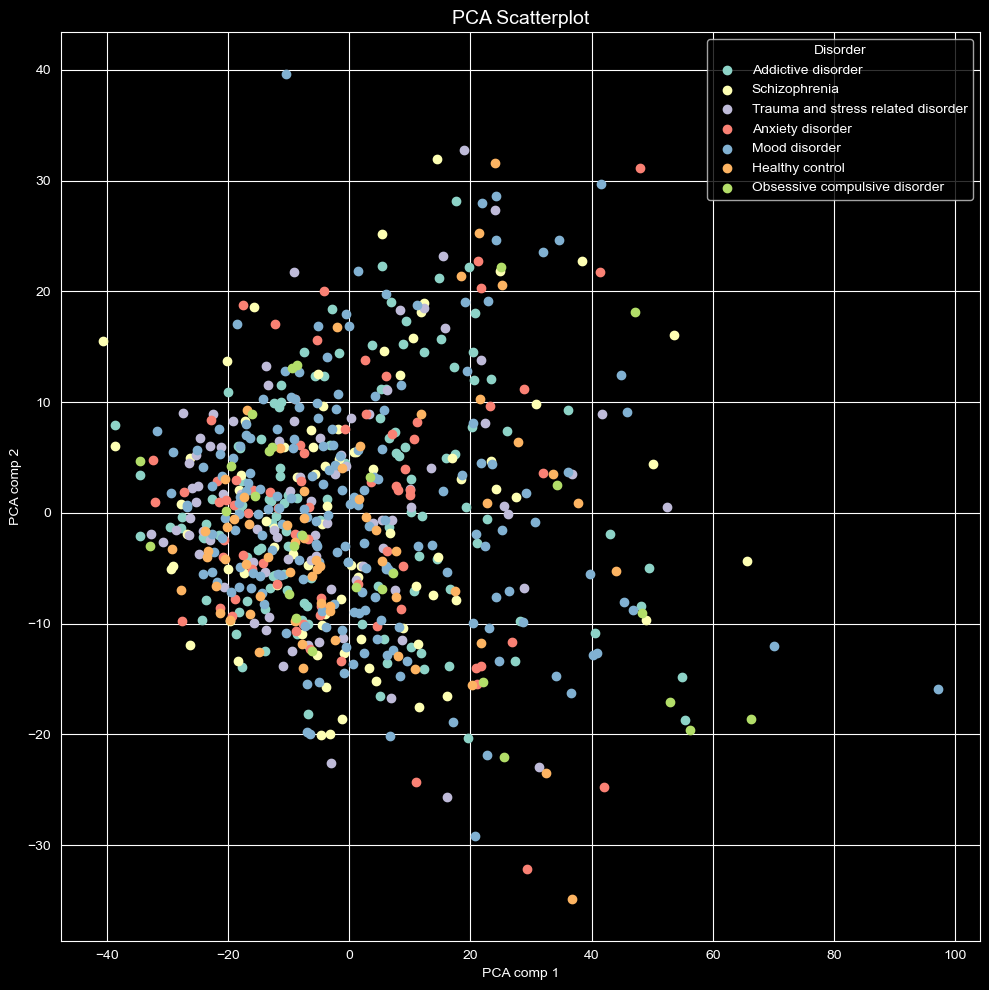

In [12]:
pca_scaled = PCA(n_components=2)
pca_scaled.fit(X_train_scaled)
scaled_pca_data = pca_scaled.transform(X_train_scaled)

plt.figure(figsize=(10,10))
for disorder in main_disorders:
    disorder_check = scaled_pca_data[y_train == disorder] # Correctly label each point (https://numpy.org/doc/stable/user/basics.indexing.html#boolean-array-indexing)
    plt.scatter(disorder_check[:,0], disorder_check[:,1], label=disorder)
plt.xlabel("PCA comp 1")
plt.ylabel("PCA comp 2")
plt.legend(title="Disorder",loc='best')
plt.title('PCA Scatterplot', fontsize=14)
plt.tight_layout()
plt.show()

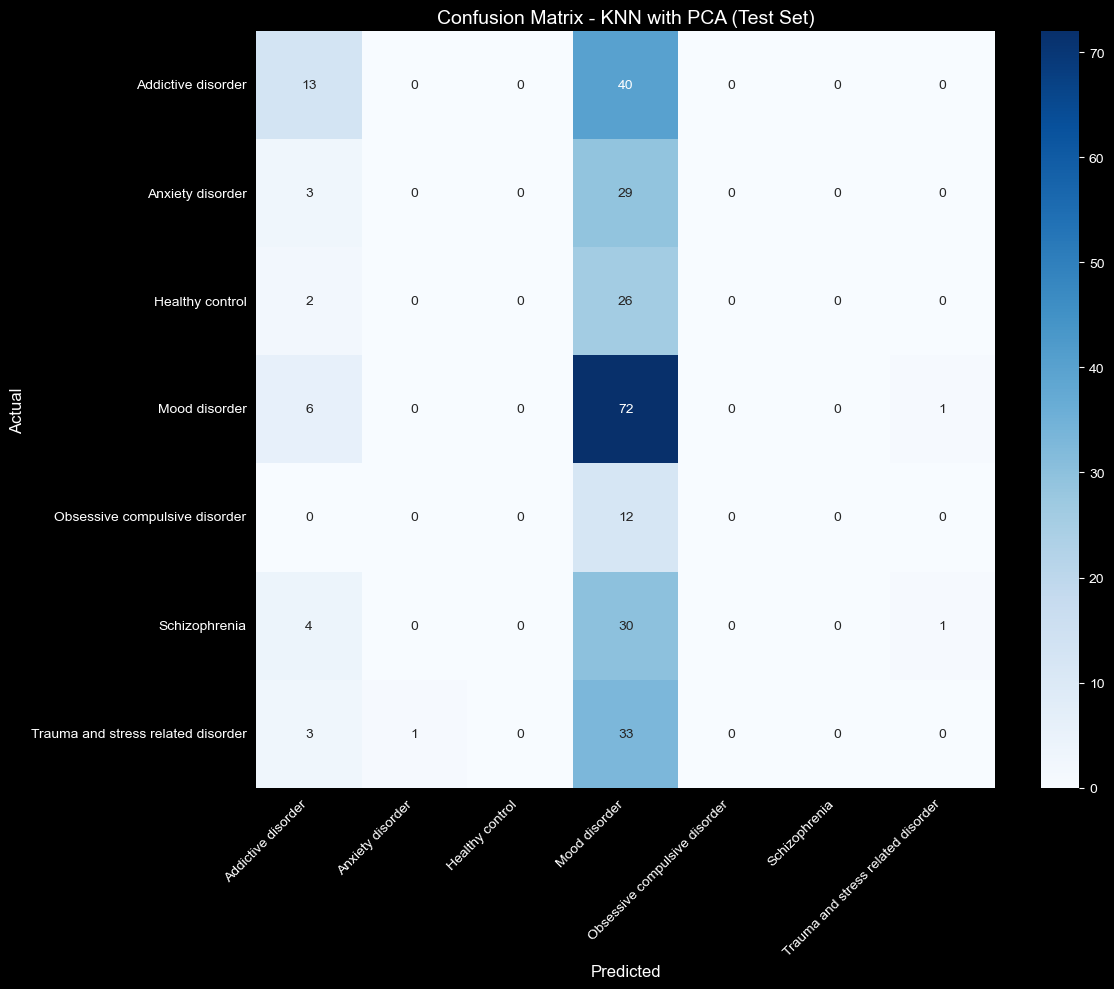

In [13]:
disorder_labels = sorted(y_test.unique())

cf = confusion_matrix(y_test, best_knn.predict(X_test_pca))

plt.figure(figsize=(12, 10))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=disorder_labels, yticklabels=disorder_labels, cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - KNN with PCA (Test Set)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# Not very good, I want at least 50% accuracy if not more
# I will try RF

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=250, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Average Accuracy ",rf_cv_scores.mean())

Average Accuracy  0.32189922480620153


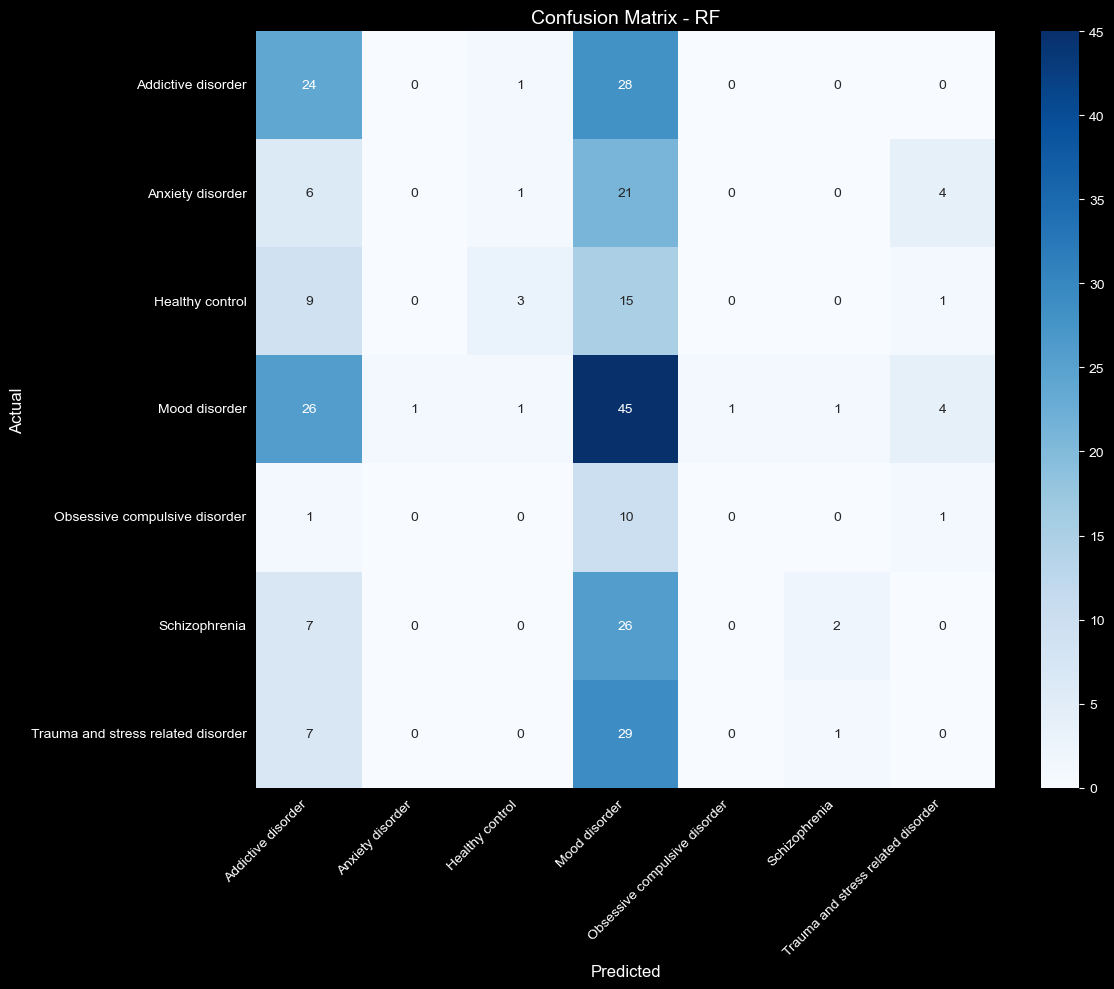

In [15]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(12, 10))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=disorder_labels, yticklabels=disorder_labels, cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Binary Classification

df.insert(6,'binary.disorder',0)

df.loc[df['main.disorder'] == 'Anxiety disorder', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

print(df['binary.disorder'].value_counts())

binary.disorder
0    720
1    106
2     93
Name: count, dtype: int64


In [17]:
non_features = ['no.', 'sex', 'age', 'eeg.date', 'education', 'IQ',
                'main.disorder', 'specific.disorder', 'Unnamed: 122', 'binary.disorder']

anxiety_healthy = df[df['binary.disorder'].isin([1, 2])]

X = anxiety_healthy.drop(columns=non_features)
y = anxiety_healthy['binary.disorder']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

Accuracy  0.6973544973544974


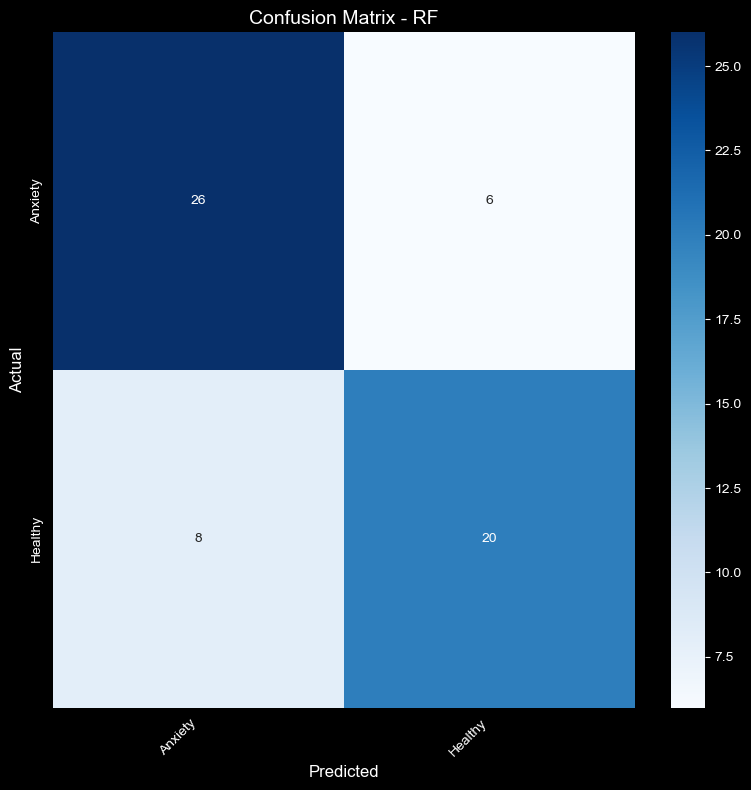

In [19]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Anxiety", "Healthy"], yticklabels=["Anxiety", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

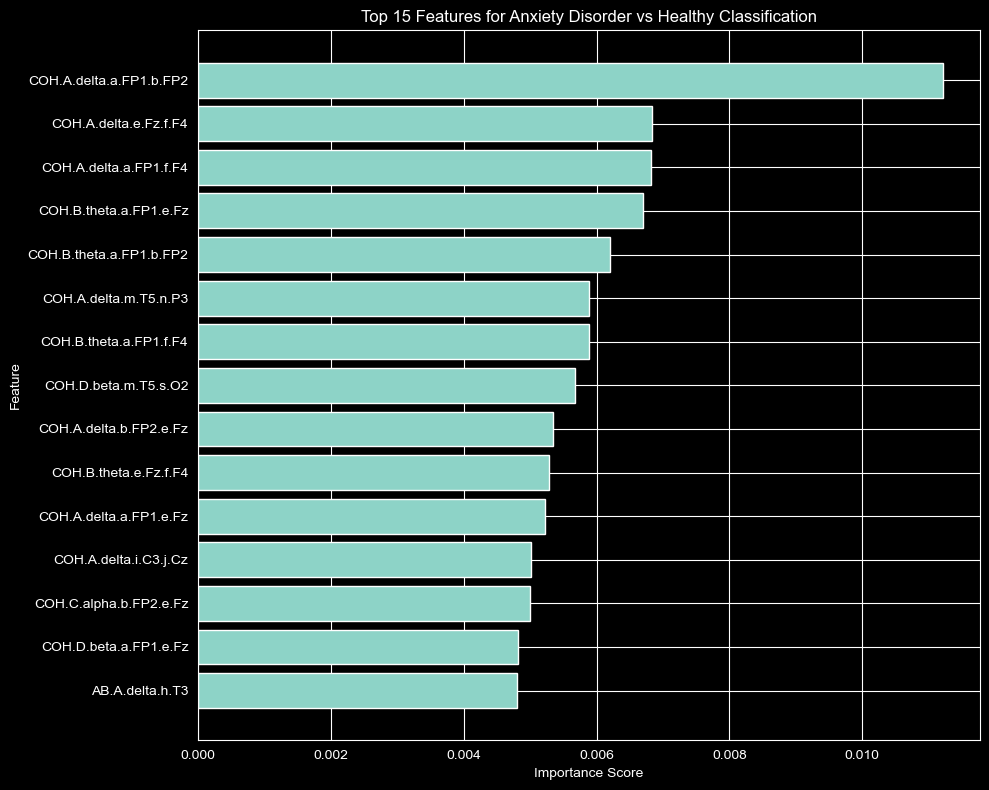

In [21]:
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Features for Anxiety Disorder vs Healthy Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
df['binary.disorder'] = 0
df.loc[df['main.disorder'] == 'Addictive disorder', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

print(df['binary.disorder'].value_counts())

addictive_healthy = df[df['binary.disorder'].isin([1, 2])]

X = addictive_healthy.drop(columns=non_features)
y = addictive_healthy['binary.disorder']

binary.disorder
0    648
1    178
2     93
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

Accuracy  0.7085348506401138


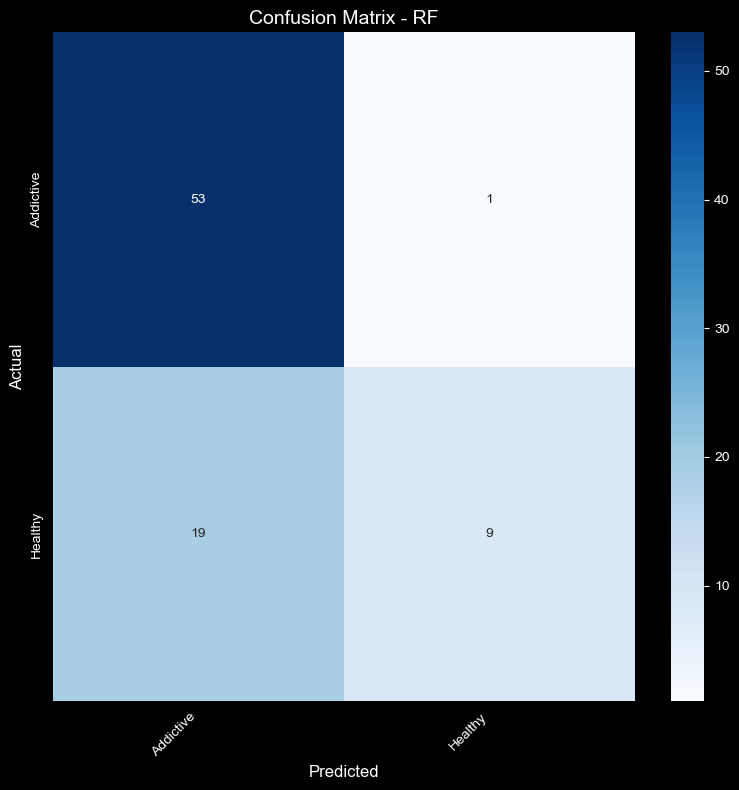

In [24]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Addictive", "Healthy"], yticklabels=["Addictive", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Class imbalance, still good accuracy

In [25]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

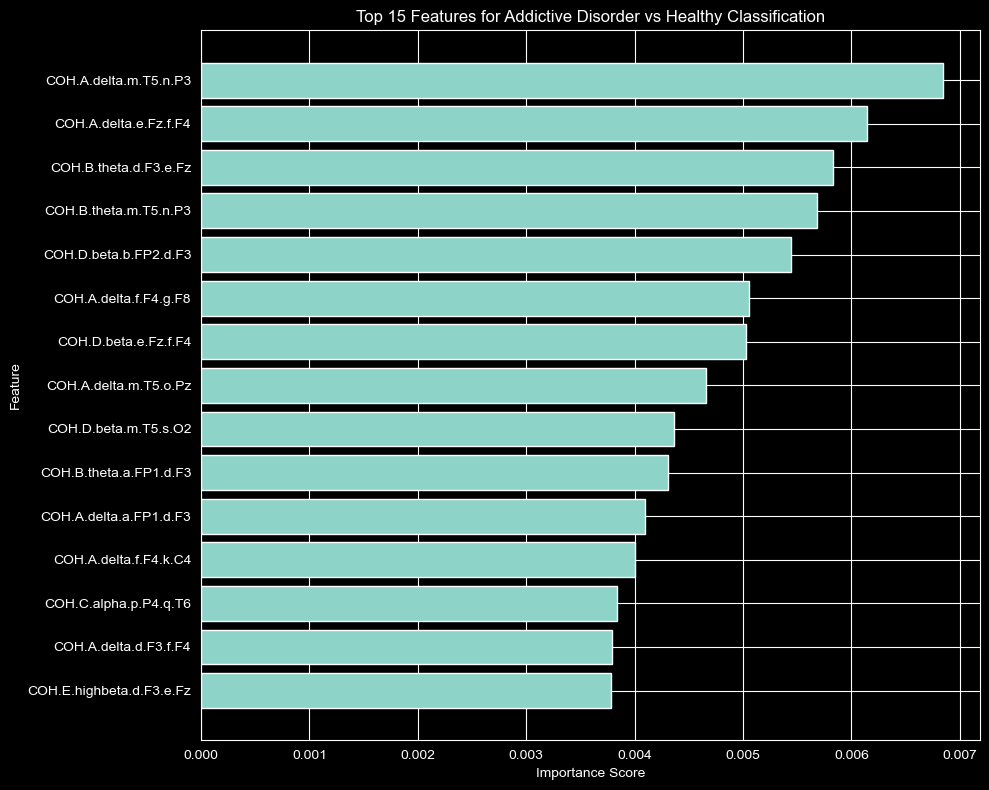

In [26]:
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Features for Addictive Disorder vs Healthy Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
df['binary.disorder'] = 0
df.loc[df['main.disorder'] == 'Mood disorder', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

print(df['binary.disorder'].value_counts())

addictive_healthy = df[df['binary.disorder'].isin([1, 2])]

X = addictive_healthy.drop(columns=non_features)
y = addictive_healthy['binary.disorder']

binary.disorder
0    564
1    262
2     93
Name: count, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

Accuracy  0.7459591836734694


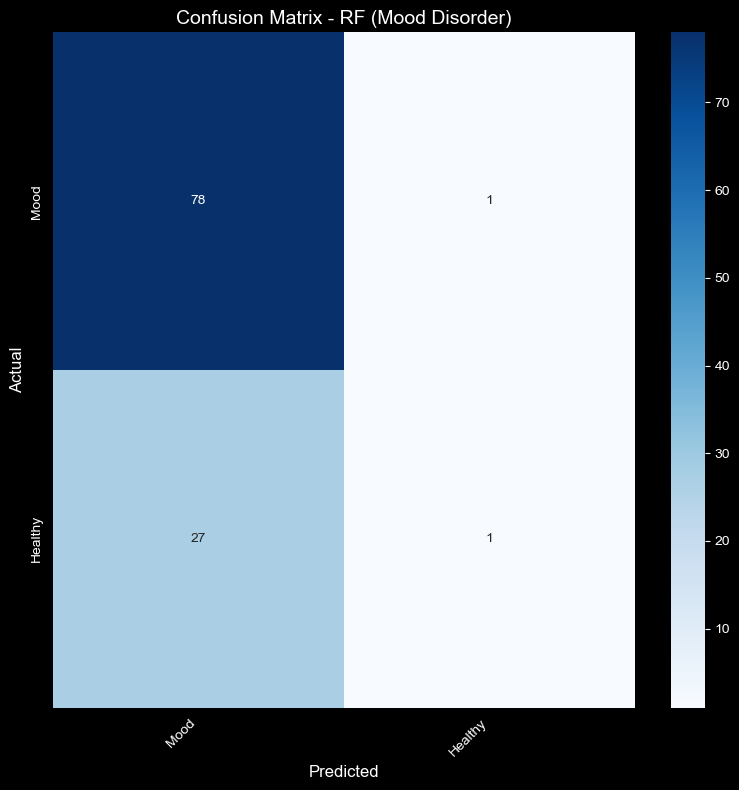

In [29]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Mood", "Healthy"], yticklabels=["Mood", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF (Mood Disorder)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Still good accuracy, more class imbalance

In [30]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

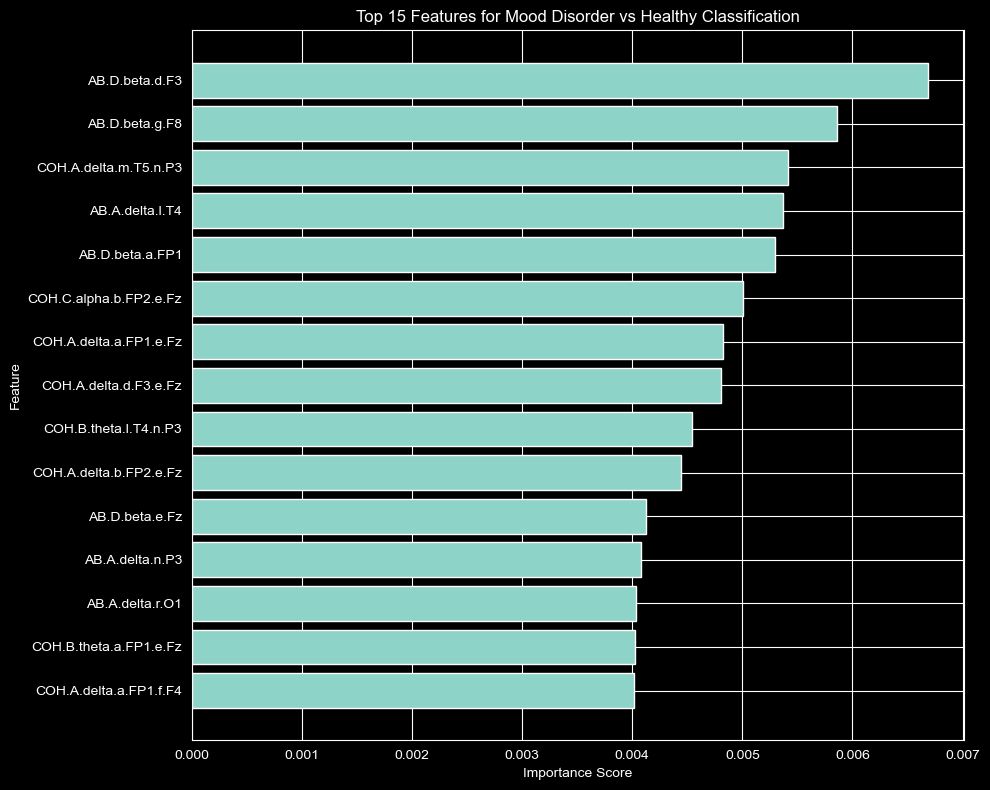

In [31]:
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Features for Mood Disorder vs Healthy Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
df['binary.disorder'] = 0
df.loc[df['main.disorder'] == 'Trauma and stress related disorder', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

print(df['binary.disorder'].value_counts())

addictive_healthy = df[df['binary.disorder'].isin([1, 2])]

X = addictive_healthy.drop(columns=non_features)
y = addictive_healthy['binary.disorder']

binary.disorder
0    703
1    123
2     93
Name: count, dtype: int64


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

Accuracy  0.7079569892473118


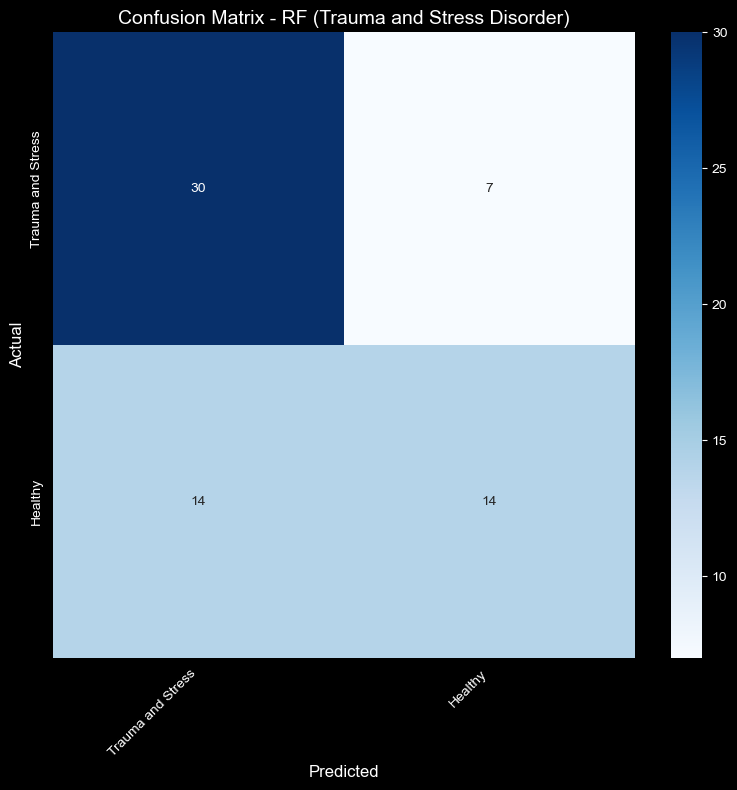

In [34]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Trauma and Stress", "Healthy"], yticklabels=["Trauma and Stress", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF (Trauma and Stress Disorder)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

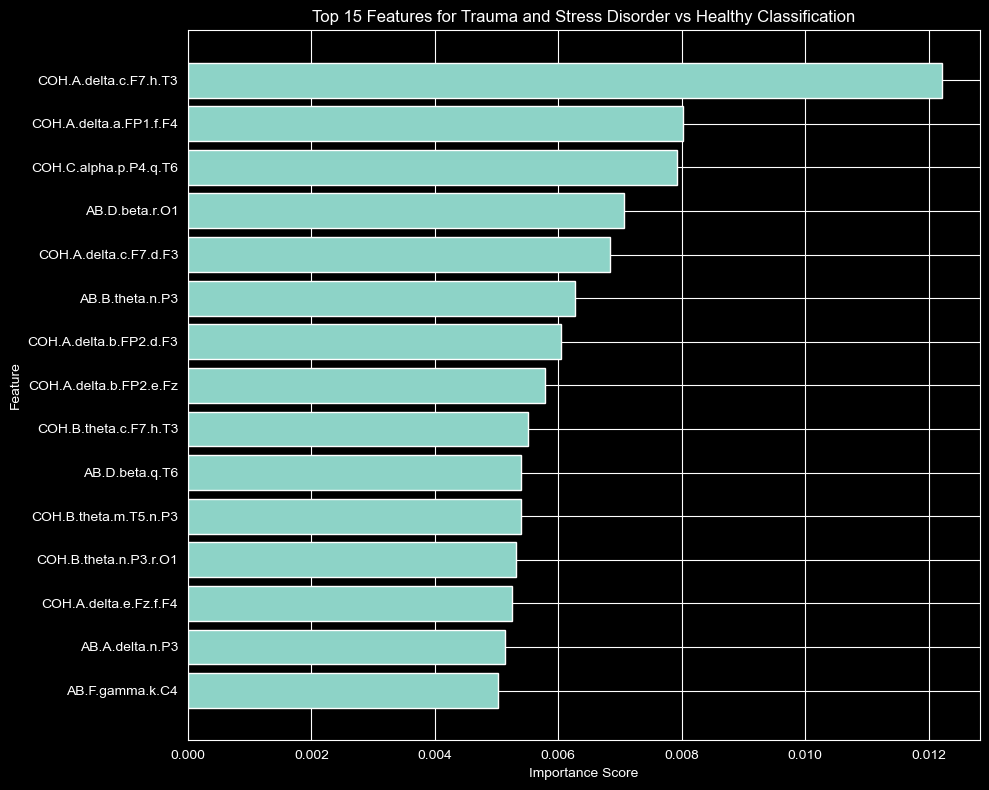

In [36]:
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Features for Trauma and Stress Disorder vs Healthy Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
df['binary.disorder'] = 0
df.loc[df['main.disorder'] == 'Obsessive compulsive disorder', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

print(df['binary.disorder'].value_counts())

addictive_healthy = df[df['binary.disorder'].isin([1, 2])]

X = addictive_healthy.drop(columns=non_features)
y = addictive_healthy['binary.disorder']

binary.disorder
0    786
2     93
1     40
Name: count, dtype: int64


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

Accuracy  0.7315789473684211


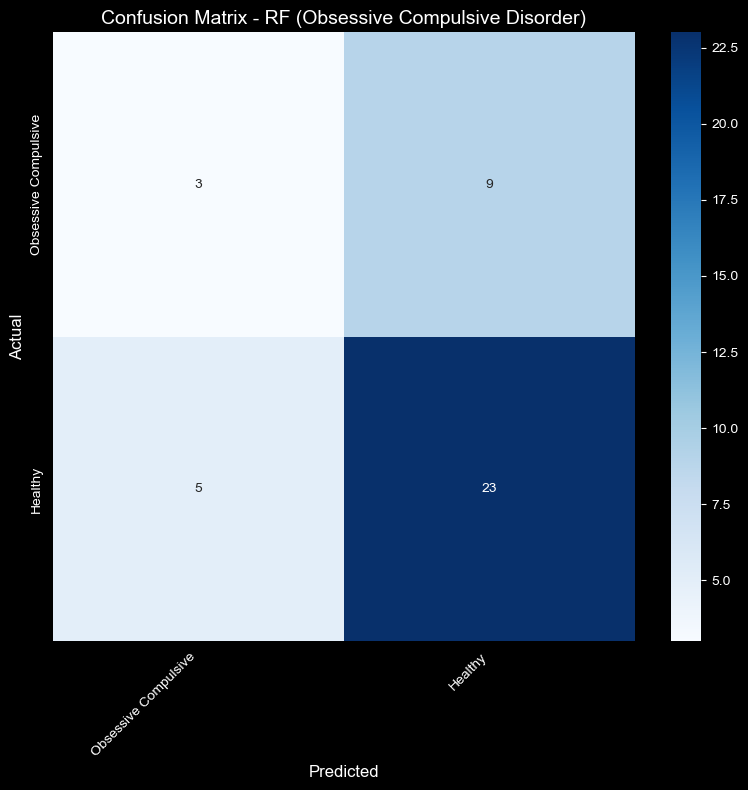

In [39]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Obsessive Compulsive", "Healthy"], yticklabels=["Obsessive Compulsive", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF (Obsessive Compulsive Disorder)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# More struggle in correctly identifying if they have this disorder or not

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

In [ ]:
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Features for Obsessive Compulsive Disorder vs Healthy Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
df['binary.disorder'] = 0
df.loc[df['main.disorder'] == 'Schizophrenia', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

print(df['binary.disorder'].value_counts())

addictive_healthy = df[df['binary.disorder'].isin([1, 2])]

X = addictive_healthy.drop(columns=non_features)
y = addictive_healthy['binary.disorder']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

In [ ]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Schizophrenia", "Healthy"], yticklabels=["Schizophrenia", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF (Schizophrenia)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Did super well for Schizophrenia!

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

In [ ]:
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Features for Schizophrenia vs Healthy Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Get only AB features
AB_cols = [col for col in df.columns if col.startswith('AB.')]

df['binary.disorder'] = 0
df.loc[df['main.disorder'] == 'Schizophrenia', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

schizo_healthy = df[df['binary.disorder'].isin([1, 2])]

X = schizo_healthy[AB_cols]
y = schizo_healthy['binary.disorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

In [ ]:
scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

In [ ]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Schizophrenia", "Healthy"], yticklabels=["Schizophrenia", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF (Schizophrenia)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Only using AB features did NOT help

In [ ]:
COH_cols = [col for col in df.columns if col.startswith('COH.')]

df['binary.disorder'] = 0
df.loc[df['main.disorder'] == 'Schizophrenia', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

schizo_healthy = df[df['binary.disorder'].isin([1, 2])]

X = schizo_healthy[COH_cols]
y = schizo_healthy['binary.disorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

In [ ]:
scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

In [ ]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Schizophrenia", "Healthy"], yticklabels=["Schizophrenia", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF (Schizophrenia)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Using coherence only features also did not help

In [ ]:
# DOCUMENTED LLM USE

# LLM Used to brainstorm approach to binary classification instead of multi-classification
# LLM Used to find resources that compare my data to real world data
# All code was taken from previous projects, knowledge, and scikit documentation.

```
Is there a way to get closer to 70% accuracy for my data
Nov 24

Honest answer: Probably not with just the raw EEG data and standard ML approaches.

Let me explain why, and what MIGHT get you to 70%:
Why 70% is Unlikely with Your Current Setup:
1. The Data Shows Massive Overlap

Your PCA plot showed all 7 disorders in one big mixed blob. That's not a limitation of the algorithm - that's the actual signal in the data.

If the disorders truly overlapped that much in EEG feature space, no algorithm can magically separate them.
2. Real-World Context

Professional research on EEG-based psychiatric diagnosis:

    Most papers report 40-60% accuracy for multi-class (5+ disorders)
    Papers claiming 70%+ often use:
        Binary classification (disorder vs healthy only)
        Very specific/clean datasets
        Deep learning on raw time-series (not pre-extracted features)
        Additional data sources (genetics, clinical interviews, fMRI)

Your 26-31% with 7 classes is actually reasonable!
What MIGHT Get You to 70%:
Option 1: Simplify the Problem (Binary Classification)

Instead of 7 classes, predict:

    Healthy vs Any Disorder (2 classes)
    Mood Disorder vs Not Mood (2 classes)

This would probably get you 60-70% because it's much easier to distinguish "something is wrong" vs "nothing is wrong."
```

```
how does my findings compare to others

Your project's findings align remarkably well with current clinical research in psychiatric neurodiagnostics. By comparing your "distinct signatures" to established medical literature, you can validate the biological relevance of your machine learning models.
Real-World Comparison Slide Content
📊 Comparison: Project Findings vs. Clinical Research
Disorder	Your Model's Signature	Clinical Literature Alignment
Schizophrenia	Widespread Delta Power & Coherence	Research confirms increased delta and theta power is a consistent finding in schizophrenia, often linked to imbalances in information processing.
Mood Disorder	Temporal-Parietal Alpha Coherence	Studies link reduced parietal alpha connectivity to symptom severity and anhedonia (the inability to feel pleasure).
OCD	Beta / Gamma Power & Coherence	High-frequency activity (Beta-Gamma) in the frontal regions is a key target for clinical neuromodulation to improve compulsivity.
Anxiety	Frontal Delta & Theta Coherence	Clinical studies use delta-beta coherence and frontal theta power as objective biomarkers for trait anxiety and emotion regulation.
Addictive Disorder	Delta + Theta + Beta / Temporal-Frontal	Addictive disorders (like Gambling Disorder) frequently show frontal hyperconnectivity across these specific frequency bands.
Key Insights for Your Presentation

    The "Binary Success" Phenomenon: You found that binary classification (e.g., Mood vs. Healthy) performed significantly better than multi-class attempts. This mirrors the "Reliability Paradox" in clinical research: while disorders have distinct group differences, they often share overlapping symptoms, making precise multi-class separation difficult for both doctors and AI.

    Widespread Slow-Wave Activity: Your finding of widespread delta/theta across multiple disorders is supported by reviews showing that increased low-frequency power is a common hallmark of "brain dysrhythmia" in psychiatric illness.

    Frontal Alpha for Trauma: Your model identified Frontal Alpha for trauma-related disorders. Real-world studies confirm alpha power deficits specifically in the medial prefrontal cortex (mPFC) of PTSD patients.
```
The alignment to each was a hyperlink, all are cited on my powerpoint and I read through the important comparisons